# 01 安装环境，跑通第一个 Notebook

本节目标：确认 Python 虚拟环境、Notebook kernel、PyTorch、常用数据处理和绘图库是否可用，并记录版本号、运行记录和遇到的问题。

## 1. 学习内容

- Python 虚拟环境：为当前项目隔离依赖，避免和系统 Python 混在一起。
- JupyterLab / Notebook：把文字、代码和运行结果放在同一个文件里。
- PyTorch：后续学习张量、自动微分和模型训练的核心库。
- Notebook 基本操作：运行 cell、查看输出、切换 kernel、保存文件。

In [4]:
import importlib.metadata as metadata
import platform
import sys

import torch


def package_version(name):
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return "not installed"


env_info = {
    "Python": sys.version.split()[0],
    "Python executable": sys.executable,
    "Platform": platform.platform(),
    "ipykernel": package_version("ipykernel"),
    "jupyterlab": package_version("jupyterlab"),
    "torch": torch.__version__,
    "pandas": package_version("pandas"),
    "matplotlib": package_version("matplotlib"),
    "CUDA available": torch.cuda.is_available(),
    "MPS available": getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available(),
}

for key, value in env_info.items():
    print(f"{key}: {value}")

Python: 3.13.12
Python executable: /Users/max/Projects/geek/ai-notebook/.venv/bin/python
Platform: macOS-26.5.1-arm64-arm-64bit-Mach-O
ipykernel: 7.3.0
jupyterlab: 4.5.8
torch: 2.12.0
pandas: 3.0.3
matplotlib: 3.11.0
CUDA available: False
MPS available: True


## 2. 跑通第一个 PyTorch cell

下面创建一个最简单的张量，并做一次加法。如果能看到输出，说明 Notebook kernel 和 PyTorch 基本可用。

In [3]:
x = torch.tensor([1, 2, 3])
y = x + 10

print("x:", x)
print("y = x + 10:", y)
print("x shape:", tuple(x.shape))
print("x dtype:", x.dtype)
print("运行成功")

x: tensor([1, 2, 3])
y = x + 10: tensor([11, 12, 13])
x shape: (3,)
x dtype: torch.int64
运行成功


## 3. 运行截图记录

下面的 cell 会把本次环境检查结果保存成一张图片：`playground/assets/01-env-check-summary.png`。

运行后也可以直接截取 notebook 输出区域，作为自己的运行截图。

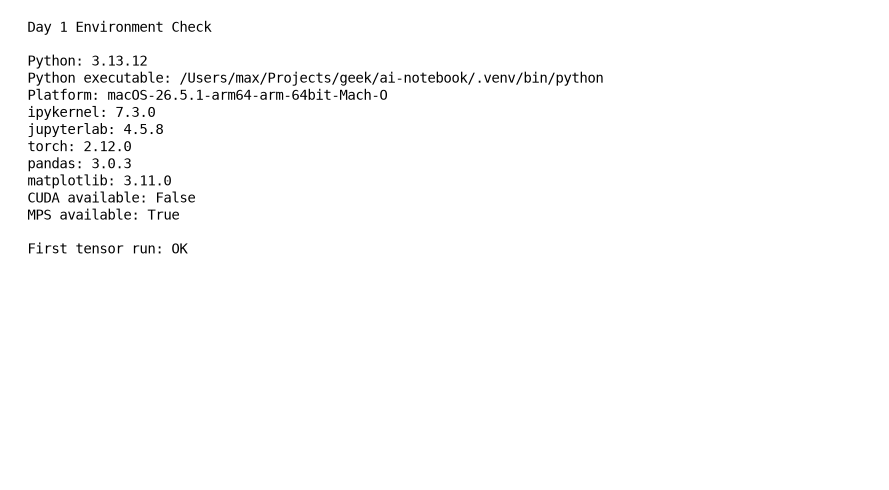

已保存运行记录图片: assets/01-env-check-summary.png


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt

assets_dir = Path("assets")
assets_dir.mkdir(exist_ok=True)
snapshot_file = assets_dir / "01-env-check-summary.png"

lines = ["Day 1 Environment Check", ""]
for key, value in env_info.items():
    lines.append(f"{key}: {value}")
lines.append("")
lines.append("First tensor run: OK")

plt.figure(figsize=(9, 5))
plt.axis("off")
plt.text(0.02, 0.98, "\n".join(lines), va="top", family="monospace", fontsize=10)
plt.tight_layout()
plt.savefig(snapshot_file, dpi=160)
plt.show()

print("已保存运行记录图片:", snapshot_file)

运行记录图片：

![Day 1 environment check](assets/01-env-check-summary.png)

## 4. 遇到的问题

- 如果 VS Code 提示缺少 `ipykernel`，说明当前 Python 环境还不能作为 notebook kernel 使用，需要安装 `ipykernel`。
- 如果 `import torch` 报错，说明 PyTorch 没有安装到当前虚拟环境。
- 如果 `jupyterlab` 显示 `not installed`，说明当前虚拟环境可以运行 notebook kernel，但还没有安装独立的 JupyterLab。需要时可安装 `jupyterlab`。
- 如果 `CUDA available` 是 `False`，不代表环境失败；Mac 或普通 CPU 环境通常没有 CUDA。
- 如果在 Apple Silicon Mac 上 `MPS available` 是 `True`，说明 PyTorch 可以使用 Apple GPU 后端。

## 小结

今天的完成标准：能打开 notebook，选中正确 kernel，运行 PyTorch 代码，并记录版本号、运行截图和遇到的问题。